# Utilisation 

## Initialiser un projet

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent   # car notebook est dans notebook/ et pas dans le root du projet
sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
from cartograpy.project import *

# Initialiser un projet avec un CRS et des dossiers par défaut
projet = Project(
    path="./mon_projet/",   # répertoire racine du projet
    data_dir="data",        # dossier des données
    output_dir="output",    # dossier des résultats
    crs="EPSG:4326"         # système de coordonnées (WGS 84)
)
projet.init()

✅ Projet initialisé dans : c:\Users\Ordinateur\OneDrive\cartograpy\notebooks\mon_projet
   📁 c:\Users\Ordinateur\OneDrive\cartograpy\notebooks\mon_projet\data
   📁 c:\Users\Ordinateur\OneDrive\cartograpy\notebooks\mon_projet\output


'c:\\Users\\Ordinateur\\OneDrive\\cartograpy\\notebooks\\mon_projet'

## Lire et écrire des données vectorielles

In [3]:
from cartograpy.data import *

In [4]:
# Lire un fichier vectoriel (GeoJSON, Shapefile, GeoPackage, etc.)
vecteur = load("../data/vector/gadm41_CIV.gpkg")
vecteur.head()

c:\Users\Ordinateur\OneDrive\cartograpy\.venv\Lib\site-packages\pyogrio\geopandas.py:382: UserWarning: More than one layer found in 'gadm41_CIV.gpkg': 'ADM_ADM_0' (default), 'ADM_ADM_1', 'ADM_ADM_2', 'ADM_ADM_3', 'ADM_ADM_4'. Specify layer parameter to avoid this warning.
  result = read_func(


,GID_0,COUNTRY,geometry
0,CIV,Côte d'Ivoire,"MULTIPOLYGON (((-4.21958 5.21986, -4.22375 5.2..."


In [5]:
# Lire un fichier GPX (traces GPS)
gpx_track = load("../data/vector/données tracées.gpx")
gpx_track.head()

,name,cmt,desc,src,link1_href,link1_text,link1_type,link2_href,link2_text,link2_type,number,type,geometry
0,2023-01-11 16:55:07WILF,None,None,None,None,None,None,None,None,None,NaN,None,"MULTILINESTRING ((-2.79985 8.04028, -2.79985 8..."
1,2023-01-11 17:13:12YLIA,None,None,None,None,None,None,None,None,None,NaN,None,"MULTILINESTRING ((-2.80003 8.03988, -2.80003 8..."
2,2023-01-12 09:13:53,None,None,None,None,None,None,None,None,None,NaN,None,"MULTILINESTRING ((-2.79987 8.04027, -2.79987 8..."
3,H023-01-11 15:57:26,None,None,None,None,None,None,None,None,None,NaN,None,"MULTILINESTRING ((-2.79978 8.04016, -2.79981 8..."


In [6]:
# Lire un fichier GPX (traces GPS)
gpx_waypoints = load("../data/vector/données tracées.gpx", layer="waypoints")  # spécifier la couche "waypoints" pour les points d'intérêt
gpx_waypoints.head()

,ele,time,magvar,geoidheight,name,cmt,desc,src,link1_href,link1_text,...,vdop,pdop,ageofdgpsdata,dgpsid,gpxx_lat,gpxx_lon,gpxx_y_proj,gpxx_x_proj,gpxx_ltime,geometry
0,NaN,2023-01-11 16:13:24+00:00,NaN,NaN,002,None,None,garmin GPSMAP 64x S,None,None,...,NaN,NaN,NaN,NaN,8.040172,-2.799787,8.040172,-2.799787,2023/01/11 16:13:24,POINT (-2.79979 8.04017)
1,NaN,2023-01-11 16:46:41+00:00,NaN,NaN,CYBER,None,None,garmin GPSMAP 64x S,None,None,...,NaN,NaN,NaN,NaN,8.040315,-2.799868,8.040315,-2.799868,2023/01/11 16:46:41,POINT (-2.79987 8.04032)
2,NaN,2023-01-11 17:02:02+00:00,NaN,NaN,ORANGE MONEY,None,None,garmin GPSMAP 64x S,None,None,...,NaN,NaN,NaN,NaN,8.039868,-2.800023,8.039868,-2.800023,2023/01/11 17:02:02,POINT (-2.80002 8.03987)
3,NaN,2023-01-11 17:22:36+00:00,NaN,NaN,003,None,None,garmin GPSMAP 64x S,None,None,...,NaN,NaN,NaN,NaN,8.040243,-2.799854,8.040243,-2.799854,2023/01/11 17:22:36,POINT (-2.79985 8.04024)
4,NaN,2023-01-11 17:24:22+00:00,NaN,NaN,ADO,None,None,garmin GPSMAP 64x S,None,None,...,NaN,NaN,NaN,NaN,8.040297,-2.799831,8.040297,-2.799831,2023/01/11 17:24:22,POINT (-2.79983 8.0403)


In [7]:
# Lire un fichier raster (GeoTIFF)
raster = load("../data/raster/DEM.tif")
print("CRS :", raster.crs)
print("Dimensions :", raster.width, "x", raster.height)
print("Emprise :", raster.bounds)
raster.close()

CRS : EPSG:4326
Dimensions : 3398 x 2011
Emprise : BoundingBox(left=-4.980416667, bottom=8.305416667, right=-2.14875, top=9.98125)


## Sauvegarder des données dans le projet

In [9]:
projet.add_data(gpx_track, "geojson", filename="données_tracées_track",overwrite=True)

✅ Fichier sauvegardé : c:\Users\Ordinateur\OneDrive\cartograpy\notebooks\mon_projet\data\données_tracées_track.geojson
✅ Données ajoutées : c:\Users\Ordinateur\OneDrive\cartograpy\notebooks\mon_projet\data\données_tracées_track.geojson


'c:\\Users\\Ordinateur\\OneDrive\\cartograpy\\notebooks\\mon_projet\\data\\données_tracées_track.geojson'

In [11]:
projet.add_data(raster, "tif", filename="données_raster", raster_meta=True, overwrite=True)

✅ Fichier sauvegardé : c:\Users\Ordinateur\OneDrive\cartograpy\notebooks\mon_projet\data\données_raster.tif
✅ Données ajoutées : c:\Users\Ordinateur\OneDrive\cartograpy\notebooks\mon_projet\data\données_raster.tif


'c:\\Users\\Ordinateur\\OneDrive\\cartograpy\\notebooks\\mon_projet\\data\\données_raster.tif'

In [12]:
save (vecteur, "geojson", "./mon_projet/data/limite_ci")

✅ Fichier sauvegardé : c:\Users\Ordinateur\OneDrive\cartograpy\notebooks\mon_projet\data\limite_ci.geojson


'c:\\Users\\Ordinateur\\OneDrive\\cartograpy\\notebooks\\mon_projet\\data\\limite_ci.geojson'

## Carte de situation de Yamoussoukro

In [13]:
from cartograpy.data import Bound

# Télécharger les frontières des pays d'Afrique de l'Ouest (ADM0)
bound = Bound()
civ = bound.get_admin("Côte d'Ivoire", adm=0)       # Côte d'Ivoire
afrique_ouest = bound.get_admin(
    ["Côte d'Ivoire", "Ghana", "Burkina Faso", "Mali", "Guinée",
     "Liberia", "Sierra Leone", "Sénégal", "Togo", "Bénin", "Niger", "Nigeria"],
    adm=0
)
afrique_ouest.head()

,geometry,shapeName,shapeISO,shapeID,shapeGroup,shapeType
0,"MULTIPOLYGON (((-7.98966 10.16199, -7.99984 10...",Côte d’Ivoire,CIV,2848817B75463690839637,CIV,ADM0
1,"POLYGON ((1.06103 6.01592, 1.06654 6.02515, 1....",Ghana,GHA,71095829B95122994846054,GHA,ADM0
2,"POLYGON ((0.9921 13.084, 0.9917 13.31368, 0.99...",Burkina Faso,BFA,72675738B40910480630913,BFA,ADM0
3,"POLYGON ((-4.83349 24.99951, -4.83971 24.99771...",Mali,MLI,8439793B10633040606991,MLI,ADM0
4,"MULTIPOLYGON (((5.63304 -1.40378, 5.63046 -1.4...",Equatorial Guinea,GNQ,36962785B17032204434992,GNQ,ADM0


<Axes: >

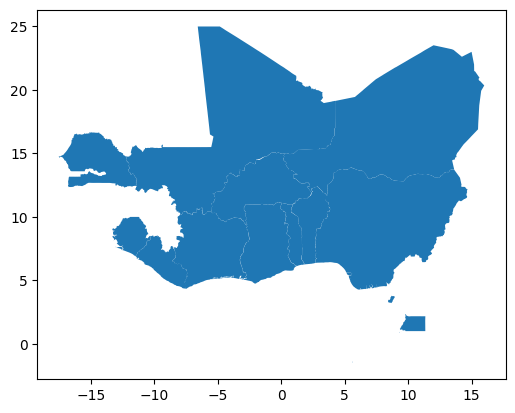

In [14]:
afrique_ouest.plot()

In [15]:
from cartograpy.mapper import *

In [ ]:
# Recharger le module mapper après correction
# import importlib
# import cartograpy.mapper
# importlib.reload(cartograpy.mapper)
# from cartograpy.mapper import Map

📄 Format de papier: A4 (landscape) - Dimensions: 210 x 297 mm - Figure: 11.7" x 8.3"
🧭 Flèche du Nord ajoutée (map-utils)
📊 Centrage intelligent appliqué:
   Format: A4 (landscape)
   Ratio figure: 1.41
   Ratio données: 0.96
   Étendue: [-10.96, -0.14, 3.72, 11.37]
🛑Element de légende ajouté None
✅ Légende personnalisée créée avec 1 éléments


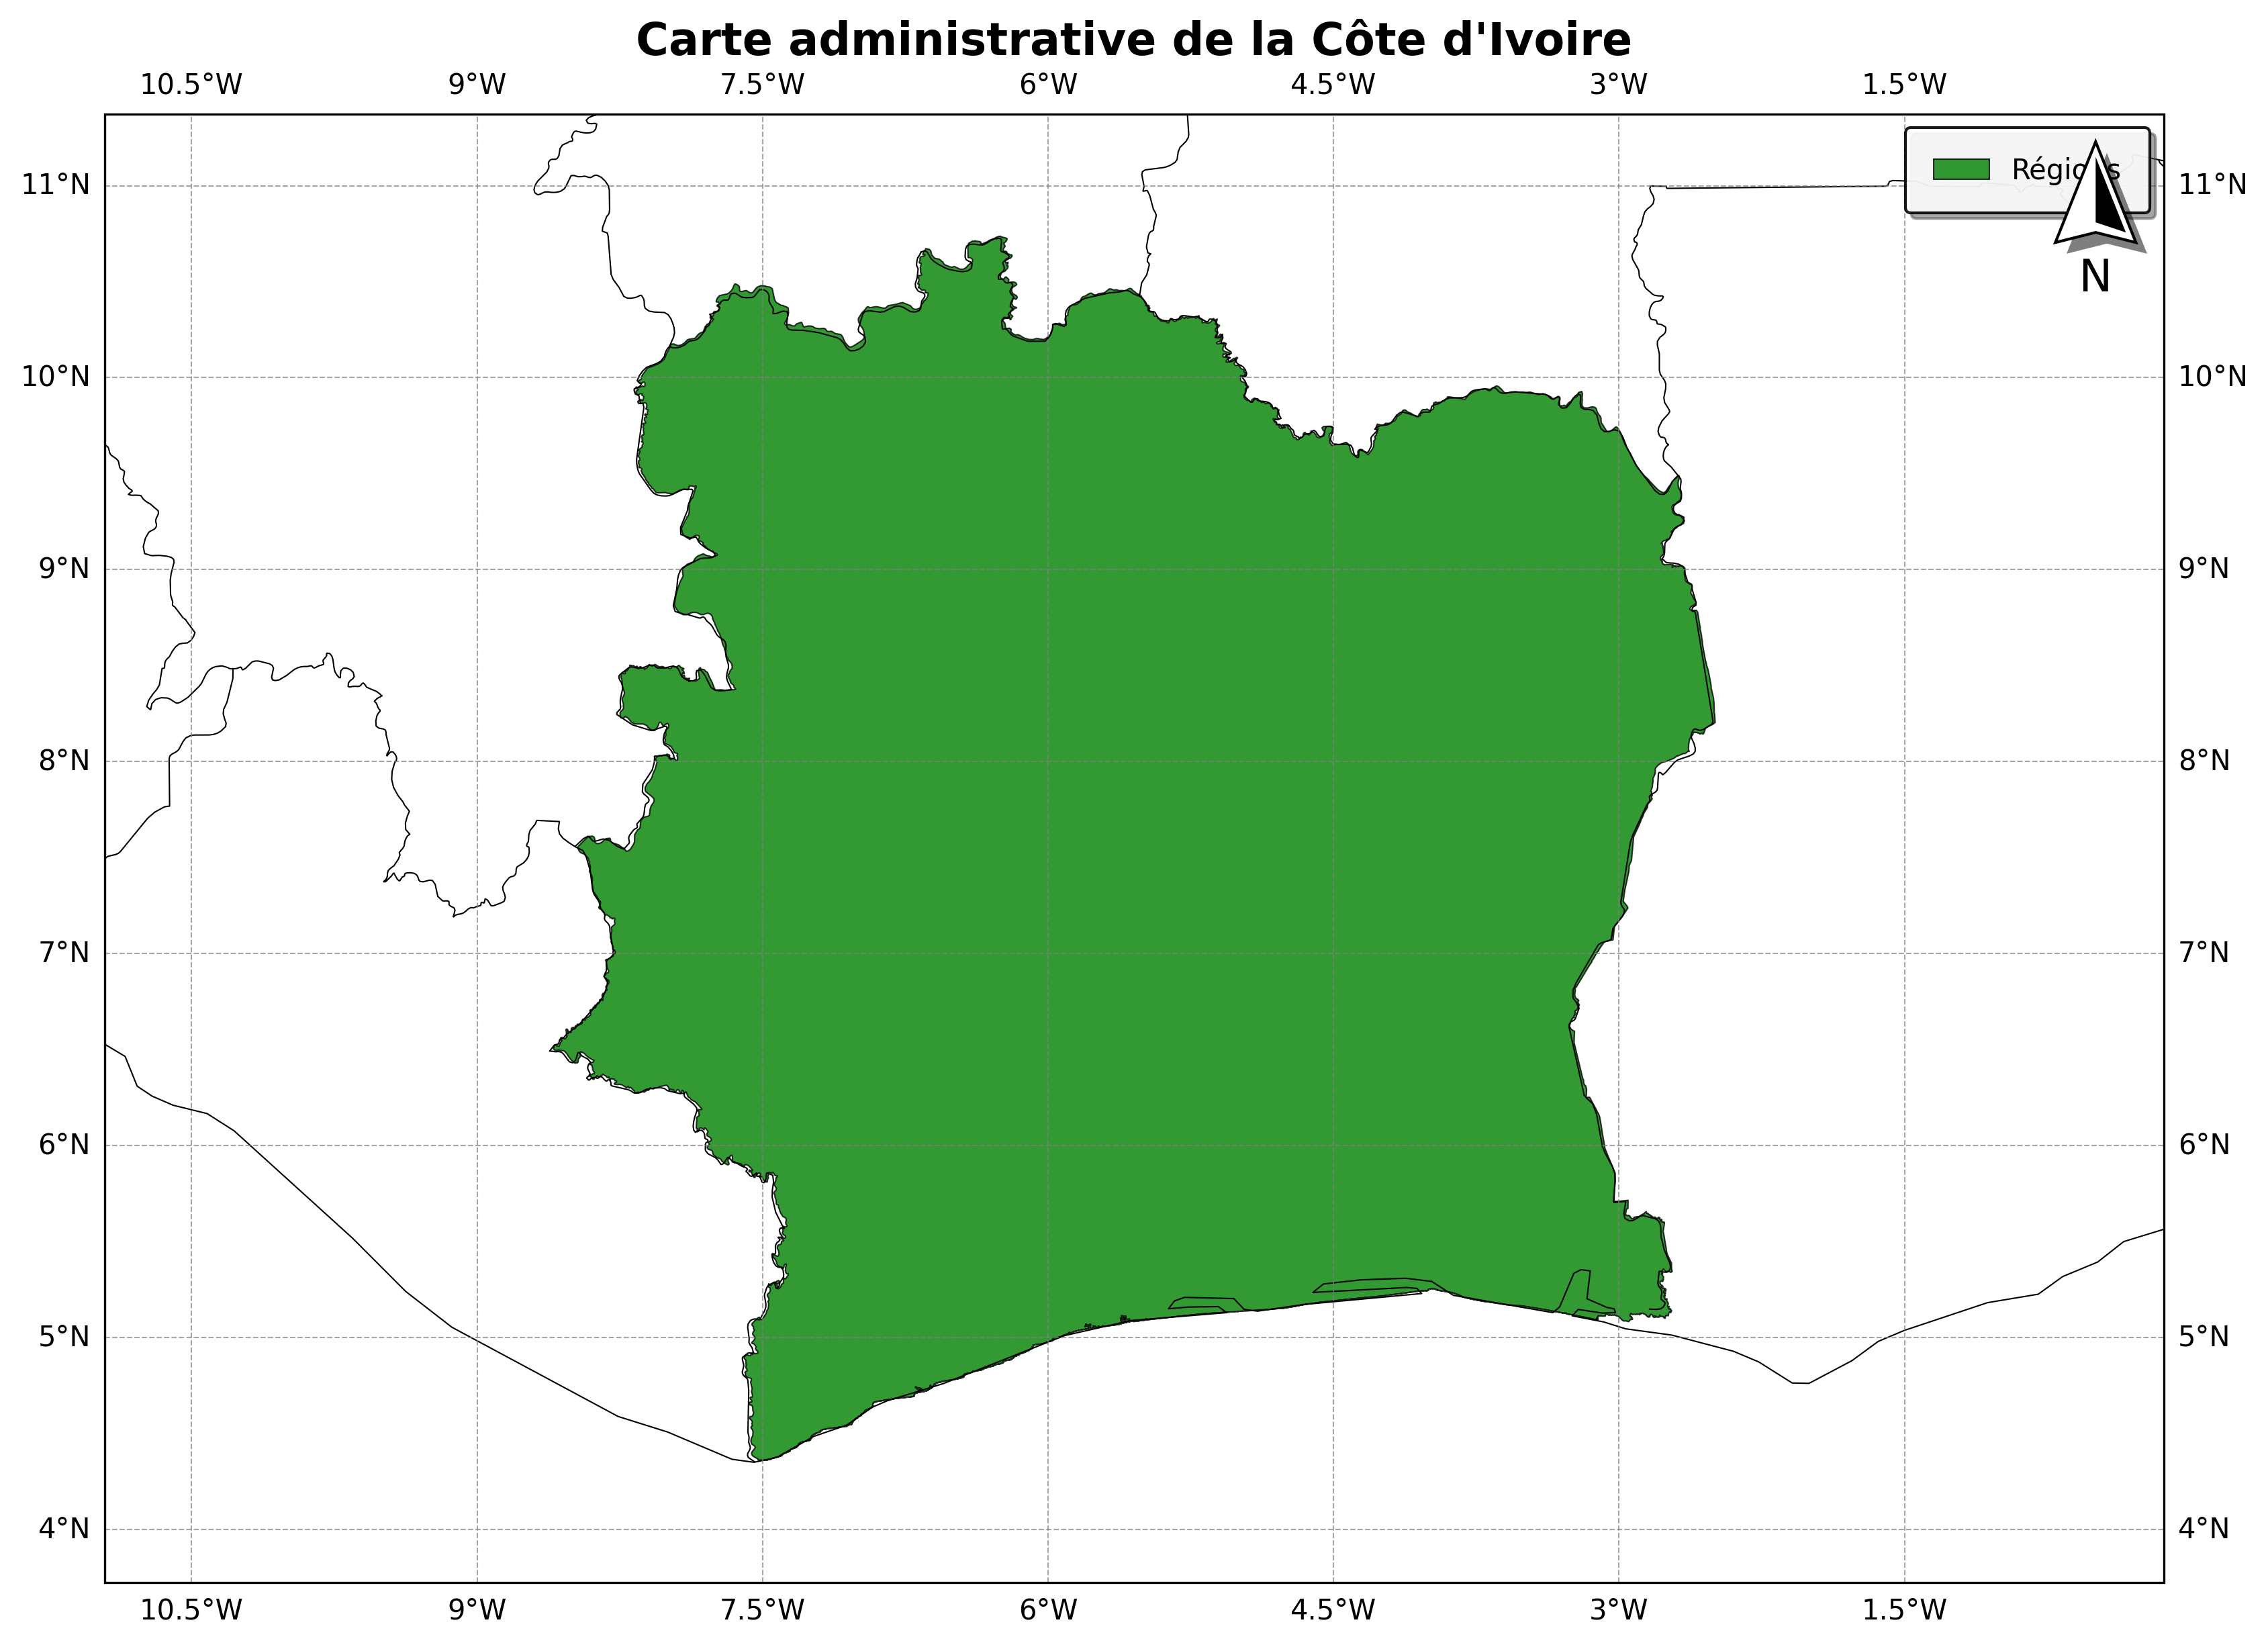

In [18]:
# Carte choroplèthe colorée selon une colonne du GeoDataFrame
m = Map(
    title="Carte administrative de la Côte d'Ivoire",
    figsize="A4",
)

# Ajouter les polygones avec coloration par colonne
m.add_polygons(
    vecteur,
    label="Régions",
    column="GID_1",
    cmap="Set3",
    edgecolor="black",
    linewidth=0.5,
    alpha=0.8,
    legend=True,
)

# Ajouter la mini-carte de situation
# m.add_inset(
#     bounds=vecteur.total_bounds.tolist(),
#     box_color="red",
#     box_linewidth=1,
#     location="lower left",
# )

m.add_gridlines()
m.add_scale_bar(length=100, location="lower left", units="km")
m.add_north_arrow()
m.show()

In [ ]:
from cartograpy.styling import *
from cartograpy.mapper import *
from cartograpy.data import *
from cartograpy.processing import *

In [ ]:
belier = bound.get_admin("CIV", adm=2).query("shapeName == 'Belier'")
belier.head()

,geometry,shapeName,shapeISO,shapeID,shapeGroup,shapeType
3,"MULTIPOLYGON (((-4.68451 6.27179, -4.68338 6.2...",Belier,,98640826B5123145245776,CIV,ADM2


In [ ]:
civ=bound.get_admin("CIV", adm=0)
civ.head()

,geometry,shapeName,shapeISO,shapeID,shapeGroup,shapeType
0,"MULTIPOLYGON (((-7.98966 10.16199, -7.99984 10...",Côte d’Ivoire,CIV,2848817B75463690839637,CIV,ADM0


📄 Format de papier: A4 (landscape) - Dimensions: 210 x 297 mm - Figure: 11.7" x 8.3"
📄 Format mis à jour: A4 (portrait) - Dimensions: 210 x 297 mm - Figure: 8.3" x 11.7"
⚠️  Attention: Aucun CRS défini. Attribution du CRS par défaut: EPSG:4326
⚠️  Attention: Aucun CRS défini. Attribution du CRS par défaut: EPSG:4326


C:\Users\Ordinateur\AppData\Local\Temp\ipykernel_20100\1052864127.py:4: UserWarning: Aucun CRS défini. Attribution du CRS par défaut: EPSG:4326
  m.add_layer(civ, label="Côte d'Ivoire", facecolor="lightyellow", edgecolor="black", linewidth=0.5)
C:\Users\Ordinateur\AppData\Local\Temp\ipykernel_20100\1052864127.py:5: UserWarning: Aucun CRS défini. Attribution du CRS par défaut: EPSG:4326
  m.add_layer(belier, label="Belier", facecolor="lightblue", edgecolor="black", linewidth=0.5)


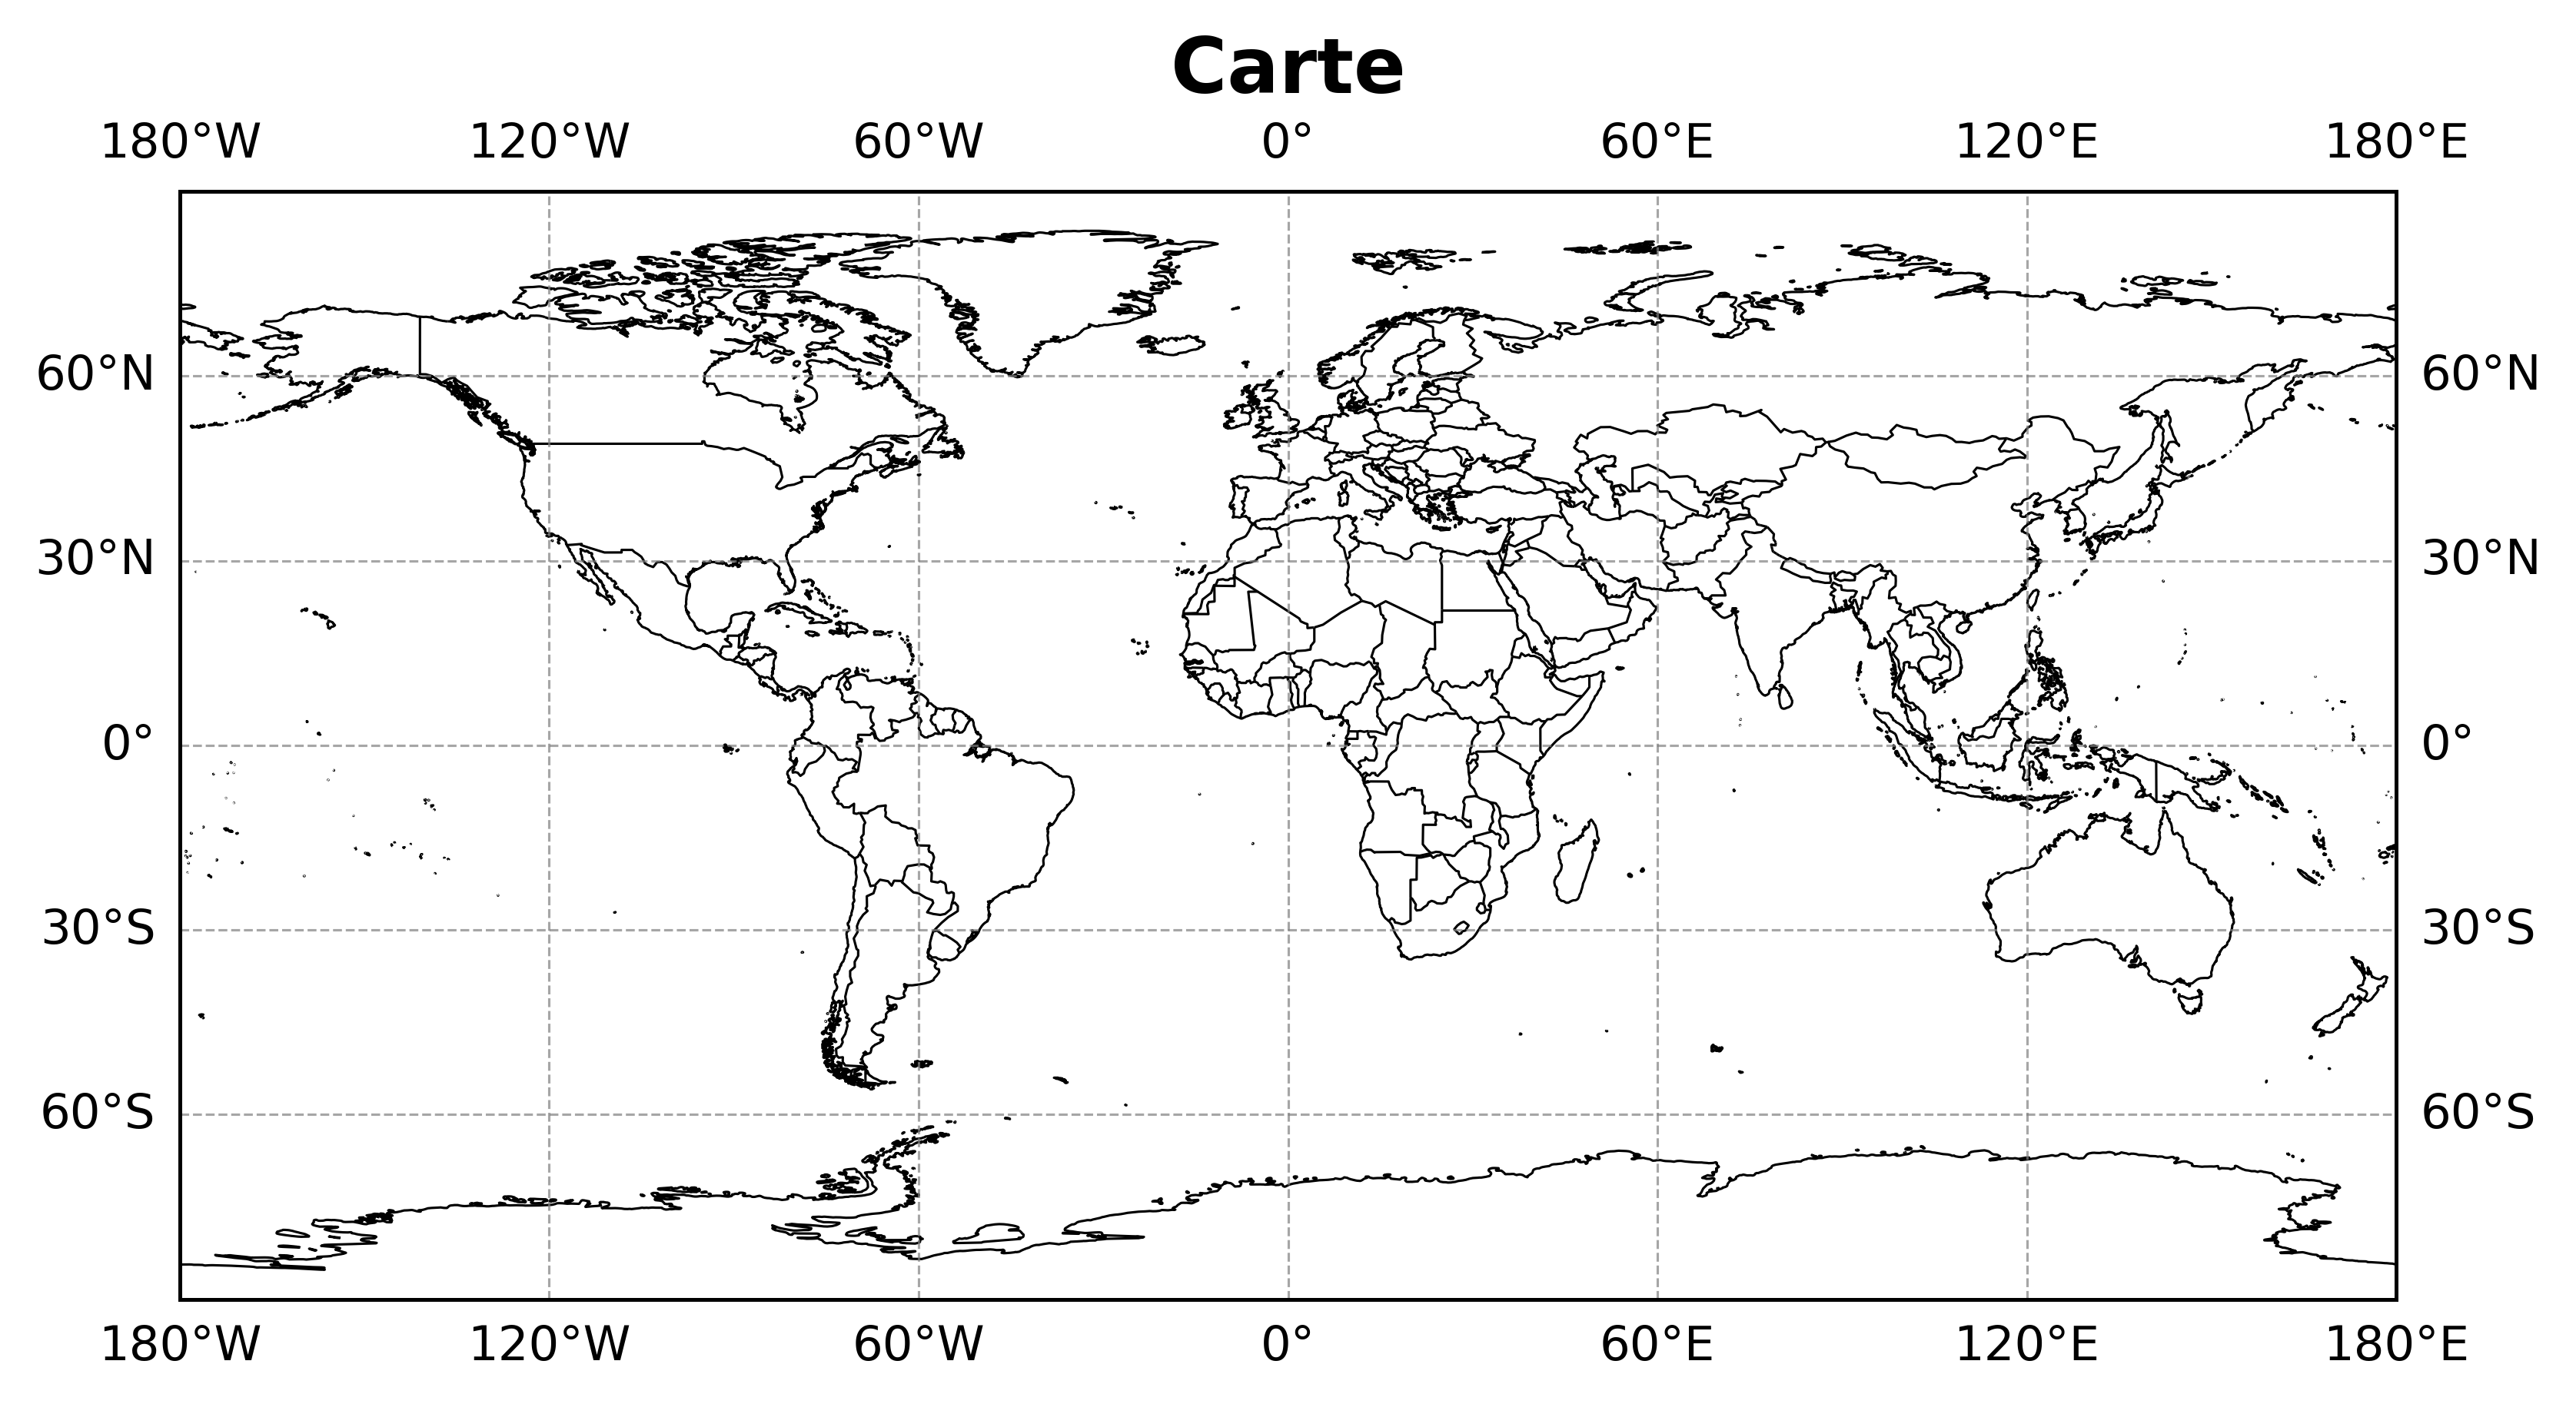

In [ ]:
m=Map("A4",dpi=450)
m.set_paper("A4",orientation="portrait")

m.add_layer(civ, label="Côte d'Ivoire", facecolor="lightyellow", edgecolor="black", linewidth=0.5)
m.add_layer(belier, label="Belier", facecolor="lightblue", edgecolor="black", linewidth=0.5)
m.add_gridlines()
m

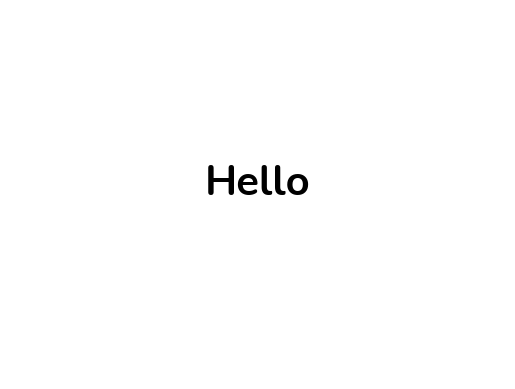

In [ ]:
import matplotlib.pyplot as plt
from cartograpy import google_font

font = google_font("Nunito", weight="bold")

fig, ax = plt.subplots()
ax.text(0.5, 0.5, "Hello", font=font, fontsize=30, ha="center")
ax.set_axis_off()
plt.show()

## Carte interactive (WebMap)

In [ ]:
from cartograpy.mapper import WebMap

# Créer une carte interactive
wm = WebMap()

# Ajouter les limites administratives
wm.add_layer(vecteur, tooltip_columns=["COUNTRY"])

# Ajouter les waypoints GPS
wm.add_layer(gpx_waypoints, tooltip_columns=["name"])

wm.show()

TypeError: Object of type Timestamp is not JSON serializable

## Traitement des données vectorielles

In [ ]:
from cartograpy.processing import centroids, fusion, join, add_column

# Calculer les centroïdes des régions
centres = centroids(vecteur)
centres.head()

C:\Users\Ordinateur\OneDrive\cartograpy\cartograpy\processing.py:26: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids_gdf['geometry'] = centroids_gdf['geometry'].centroid
c:\Users\Ordinateur\OneDrive\cartograpy\.venv\Lib\site-packages\pandas\core\generic.py:6335: DeprecationWarning: Overriding the CRS of a GeoDataFrame that already has CRS. This unsafe behavior will be deprecated in future versions. Use GeoDataFrame.set_crs method instead
  return object.__setattr__(self, name, value)


,GID_0,COUNTRY,geometry
0,CIV,Côte d'Ivoire,POINT (-5.55542 7.62557)


In [ ]:
# Ajouter une colonne calculée (superficie en km²)
vecteur_avec_surface = add_column(
    vecteur.to_crs(epsg=32630),  # UTM zone 30N pour la CIV
    "superficie_km2",
    lambda df: df.geometry.area / 1e6,
).to_crs(epsg=4326)

vecteur_avec_surface[["NAME_1", "superficie_km2"]].head()

KeyError: "['NAME_1'] not in index"

In [ ]:
# Jointure spatiale : associer les waypoints GPS aux régions
resultat_jointure = join(
    (gpx_waypoints, "points GPS"),
    (vecteur, "régions"),
)
resultat_jointure.head()

ValueError: La colonne 'points GPS' n'existe pas dans le GeoDataFrame source

## Téléchargement de données géographiques

In [ ]:
from cartograpy.data import Bound, OSM

# Télécharger les limites d'un pays via GeoBoundaries
bound = Bound()
civ = bound.get_country("Côte d'Ivoire")
civ.head()

,geometry,shapeName,shapeISO,shapeID,shapeGroup,shapeType
0,"MULTIPOLYGON (((-7.98966 10.16199, -7.99984 10...",Côte d’Ivoire,CIV,2848817B75463690839637,CIV,ADM0


In [ ]:
# Télécharger des données OSM (écoles de Yamoussoukro)
osm = OSM()
ecoles = osm.get_data("Yamoussoukro, Côte d'Ivoire", tags={"amenity": "school"}, data_type="points")
ecoles.head()

geometry amenity  \
element id                                              
node    4323509299    POINT (-5.27446 6.8259)  school   
        6968420931   POINT (-5.25279 6.80537)  school   
        11760754758  POINT (-5.19458 6.82377)  school   
        11764296908  POINT (-5.29628 6.82145)  school   
        11767614541  POINT (-5.39716 6.87355)  school   

                                        name                   website  \
element id                                                               
node    4323509299      Collège Google Sephy                       NaN   
        6968420931       Pigier Yamoussoukro  https://www.pigierci.com   
        11760754758                      NaN                       NaN   
        11764296908  Collège Privé Dieudonné                       NaN   
        11767614541                      NaN                       NaN   

                    isced:level short_name architect old_name school:FR  \
element id                                                                
node    4323509299          NaN        NaN       NaN      NaN       NaN   
        6968420931          NaN        NaN       NaN      NaN       NaN   
        11760754758         NaN        NaN       NaN      NaN       NaN   
        11764296908     College        NaN       NaN      NaN       NaN   
        11767614541         NaN        NaN       NaN      NaN       NaN   

                    start_date  ... wheelchair addr:street contact:phone  \
element id                      ...                                        
node    4323509299         NaN  ...        NaN         NaN           NaN   
        6968420931         NaN  ...        NaN         NaN           NaN   
        11760754758        NaN  ...        NaN         NaN           NaN   
        11764296908        NaN  ...        NaN         NaN           NaN   
        11767614541        NaN  ...        NaN         NaN           NaN   

                    name:en contact:email contact:facebook contact:website  \
element id                                                                   
node    4323509299      NaN           NaN              NaN             NaN   
        6968420931      NaN           NaN              NaN             NaN   
        11760754758     NaN           NaN              NaN             NaN   
        11764296908     NaN           NaN              NaN             NaN   
        11767614541     NaN           NaN              NaN             NaN   

                    full_name religion addr:postcode  
element id                                            
node    4323509299        NaN      NaN           NaN  
        6968420931        NaN      NaN           NaN  
        11760754758       NaN      NaN           NaN  
        11764296908       NaN      NaN           NaN  
        11767614541       NaN      NaN           NaN  

[5 rows x 28 columns]

In [ ]:
# Visualiser les écoles sur une carte interactive
wm2 = WebMap(title="Écoles de Yamoussoukro")
wm2.add_layer(ecoles, tooltip_columns=["name"])
wm2.show()

TypeError: WebMap.__init__() got an unexpected keyword argument 'title'